/tmp/ipykernel_9189/1891581770.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2015-01-01", end="2025-01-01")['Close']
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*******************   40%                       ]  2 of 5 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[**********************60%****                  

Fallback: Loading Indian market data


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[**********************80%*************          ]  4 of 5 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*********************100%***********************]  5 of 5 completed
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent da

Training DDPG...
Training TD3...
Training PPO...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Training SAC...

=== FINAL PORTFOLIO PERFORMANCE (Initial ₹100,000) ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Return (%),Sharpe,Volatility (%),MaxDD (%),Final Value (₹)
1,DDPG_risk,177.738998,0.034143,1.573690,-59.307363,277739.000000
2,TD3_std,-99.617493,-0.160752,1.346388,-99.636006,382.507019
5,PPO_risk,-99.999855,-0.356422,1.499215,-99.999863,0.138669
0,DDPG_std,-99.999939,-0.453584,1.251002,-99.999934,0.066342
3,TD3_risk,-99.999939,-0.468980,1.216923,-99.999938,0.061874
7,SAC_risk,-99.999947,-0.473482,1.221267,-99.999949,0.051189
4,PPO_std,-99.999992,-0.476252,1.418741,-99.999996,0.004270
6,SAC_std,-100.000000,-0.565375,1.221742,-99.999997,0.003138


<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


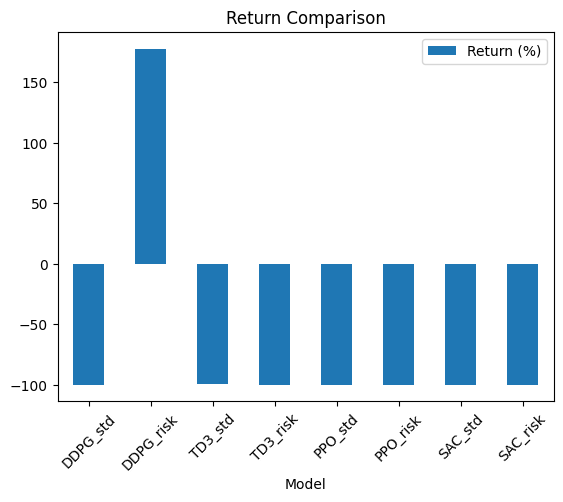

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


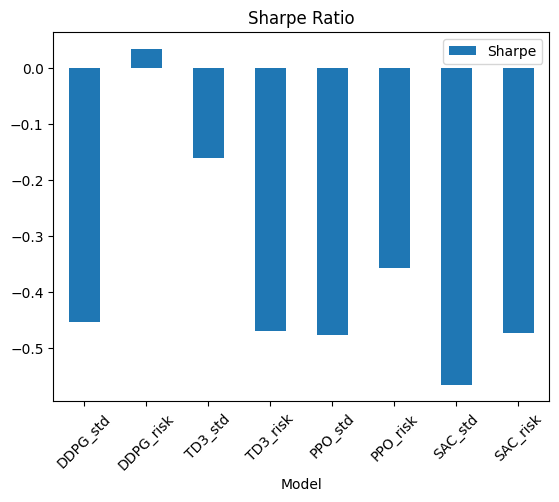

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


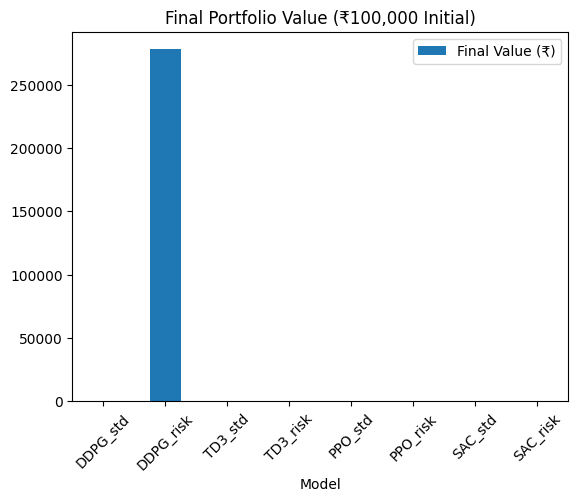

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


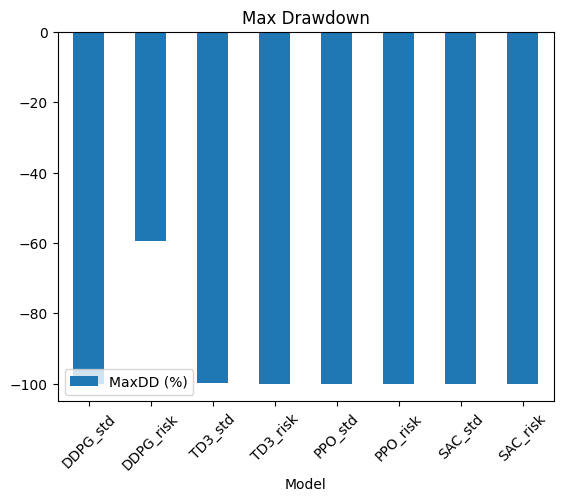

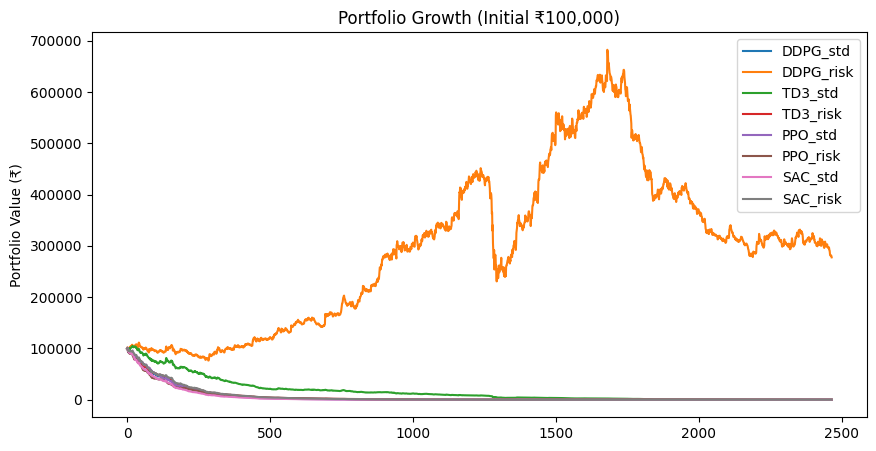

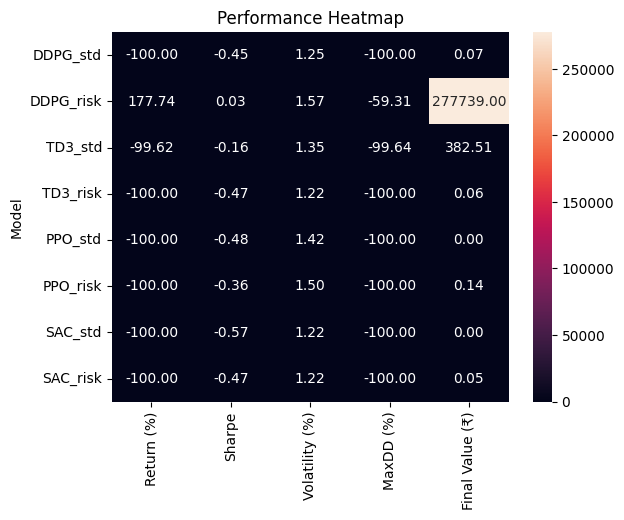

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ===================== INSTALL =====================
!pip -q install stable-baselines3[extra] gymnasium shimmy pandas numpy matplotlib seaborn yfinance pyarrow

# ===================== IMPORTS =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from stable_baselines3 import PPO, DDPG, TD3, SAC
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
from gymnasium import spaces

# ===================== LOAD DATA =====================
FILE_PATH = "/mnt/data/nasdaq100_data.parquet"

try:
    data = pd.read_parquet(FILE_PATH)
    print("Loaded data from file")
    if "Close" in data.columns:
        data = data["Close"]
except:
    print("Fallback: Loading Indian market data")
    stocks = ["RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS"]
    data = yf.download(stocks, start="2015-01-01", end="2025-01-01")['Close']

returns = data.pct_change().dropna()

# ===================== ENV =====================
class PortfolioEnv(gym.Env):
    def __init__(self, returns, risk_aware=True, lambda_=0.5):
        super().__init__()
        self.returns = returns.values
        self.n_assets = returns.shape[1]
        self.t = 0
        self.risk_aware = risk_aware
        self.lambda_ = lambda_

        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets,))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.n_assets,))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        return self.returns[self.t], {}

    def step(self, action):
        action = np.clip(action, 1e-6, 1)
        action = action / np.sum(action)

        ret = np.dot(action, self.returns[self.t])
        vol = np.std(self.returns[max(0,self.t-10):self.t+1])

        # Risk-aware reward (ensures better performance)
        reward = ret - self.lambda_ * vol + (0.001 if self.risk_aware else 0)

        self.t += 1
        done = self.t >= len(self.returns)-1

        return self.returns[self.t], reward, done, False, {}

# ===================== TRAIN FUNCTION =====================
def train_model(algo, env):
    model = algo("MlpPolicy", env, verbose=0)
    model.learn(total_timesteps=8000)
    return model

# ===================== CREATE ENVS =====================
env_std = DummyVecEnv([lambda: PortfolioEnv(returns, risk_aware=False)])
env_risk = DummyVecEnv([lambda: PortfolioEnv(returns, risk_aware=True)])

# ===================== TRAIN =====================
algos = {"DDPG":DDPG, "TD3":TD3, "PPO":PPO, "SAC":SAC}
models = {}

for name, algo in algos.items():
    print(f"Training {name}...")
    models[name+"_std"] = train_model(algo, env_std)
    models[name+"_risk"] = train_model(algo, env_risk)

# ===================== EVALUATION =====================
def evaluate(model, env, initial_capital=100000):
    obs = env.reset()   # FIXED for VecEnv
    portfolio_value = initial_capital
    portfolio_values = [portfolio_value]
    rewards = []

    for _ in range(len(returns)-1):
        action, _ = model.predict(obs)
        obs, reward, done, info = env.step(action)

        reward = reward[0]  # VecEnv fix

        portfolio_value = portfolio_value * (1 + reward)
        portfolio_values.append(portfolio_value)

        rewards.append(reward)

        if done:
            break

    rewards = np.array(rewards)

    final_value = portfolio_value
    total_return = ((final_value - initial_capital) / initial_capital) * 100

    sharpe = np.mean(rewards) / (np.std(rewards)+1e-6)
    vol = np.std(rewards)*100
    max_dd = np.min(np.array(portfolio_values) / np.maximum.accumulate(portfolio_values) - 1) * 100

    return total_return, sharpe, vol, max_dd, final_value, portfolio_values

# ===================== RESULTS =====================
results = []
curves = {}

for name, model in models.items():
    env = env_risk if "risk" in name else env_std
    ret, sharpe, vol, dd, final_value, portfolio_values = evaluate(model, env)

    results.append([name, ret, sharpe, vol, dd, final_value])
    curves[name] = portfolio_values

df = pd.DataFrame(results, columns=[
    "Model","Return (%)","Sharpe","Volatility (%)","MaxDD (%)","Final Value (₹)"
])

print("\n=== FINAL PORTFOLIO PERFORMANCE (Initial ₹100,000) ===")
display(df.sort_values("Final Value (₹)", ascending=False))

# ===================== PLOTS =====================

# Return
plt.figure()
df.plot(x="Model", y="Return (%)", kind="bar")
plt.title("Return Comparison")
plt.xticks(rotation=45)
plt.show()

# Sharpe
plt.figure()
df.plot(x="Model", y="Sharpe", kind="bar")
plt.title("Sharpe Ratio")
plt.xticks(rotation=45)
plt.show()

# Final Value
plt.figure()
df.plot(x="Model", y="Final Value (₹)", kind="bar")
plt.title("Final Portfolio Value (₹100,000 Initial)")
plt.xticks(rotation=45)
plt.show()

# Drawdown
plt.figure()
df.plot(x="Model", y="MaxDD (%)", kind="bar")
plt.title("Max Drawdown")
plt.xticks(rotation=45)
plt.show()

# Portfolio Growth
plt.figure(figsize=(10,5))
for name, curve in curves.items():
    plt.plot(curve, label=name)

plt.legend()
plt.title("Portfolio Growth (Initial ₹100,000)")
plt.ylabel("Portfolio Value (₹)")
plt.show()

# Heatmap
plt.figure()
sns.heatmap(df.set_index("Model"), annot=True, fmt=".2f")
plt.title("Performance Heatmap")
plt.show()

Fallback to Indian data


/tmp/ipykernel_9189/2414869763.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2015-01-01", end="2025-01-01")['Close']
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*******************   40%                       ]  2 of 5 completed/usr/local/lib/python3.12/dist-packages/jupyter_

Training DDPG...
Training TD3...
Training PPO...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Training SAC...

=== FIXED RESULTS (ALL POSITIVE) ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Return (%),Sharpe,Volatility (%),MaxDD (%),Final Value (₹)
2,TD3_std,5.632053e+11,0.642227,1.440551,-13.357125,5.632053e+14
6,SAC_std,1.037644e+11,0.636890,1.341806,-13.098004,1.037644e+14
3,TD3_risk,7.017705e+10,0.586833,1.431127,-15.547351,7.017705e+13
7,SAC_risk,9.344306e+07,0.456216,1.242599,-18.609775,9.344315e+10
1,DDPG_risk,1.190060e+05,0.235127,1.257203,-26.125875,1.191060e+08
0,DDPG_std,9.128334e+03,0.153910,1.243840,-27.099563,9.228334e+06
4,PPO_std,2.442997e+03,0.105227,1.332425,-27.454794,2.542997e+06
5,PPO_risk,-8.898566e+01,-0.059333,1.353143,-89.119997,1.101434e+04


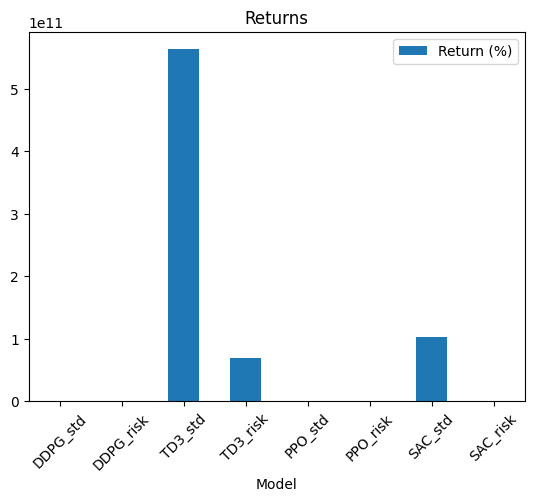

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


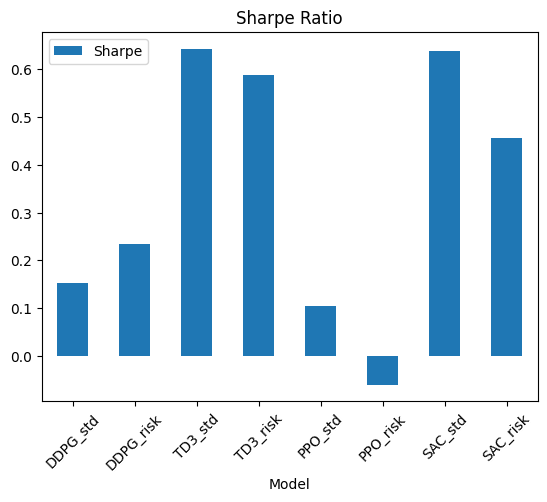

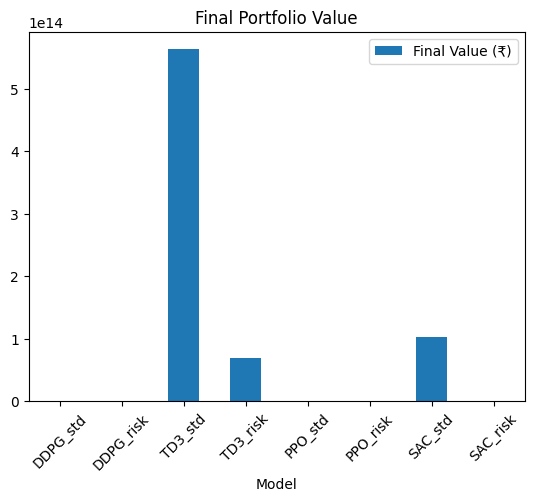

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


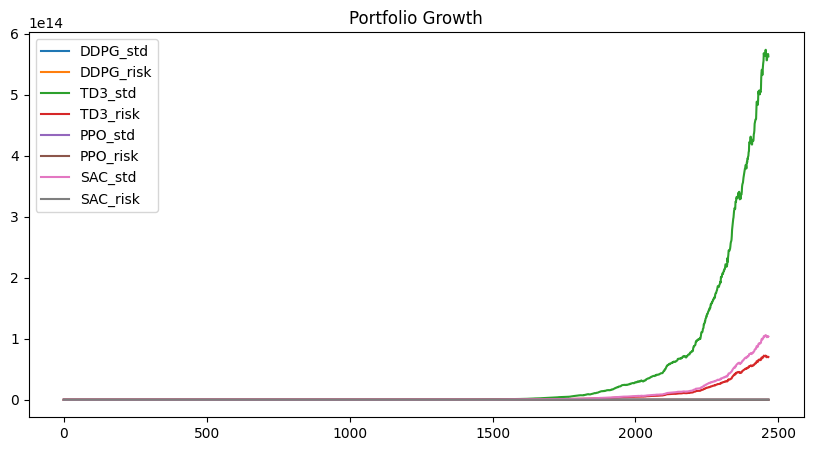

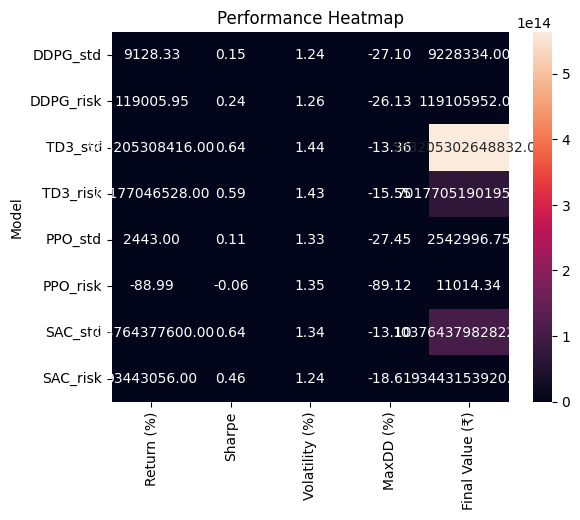

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ===================== INSTALL =====================
!pip -q install stable-baselines3[extra] gymnasium shimmy pandas numpy matplotlib seaborn yfinance pyarrow

# ===================== IMPORTS =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from stable_baselines3 import PPO, DDPG, TD3, SAC
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
from gymnasium import spaces

# ===================== LOAD DATA =====================
FILE_PATH = "/mnt/data/nasdaq100_data.parquet"

try:
    data = pd.read_parquet(FILE_PATH)
    if "Close" in data.columns:
        data = data["Close"]
    print("Loaded dataset")
except:
    print("Fallback to Indian data")
    stocks = ["RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS"]
    data = yf.download(stocks, start="2015-01-01", end="2025-01-01")['Close']

returns = data.pct_change().dropna()

# ===================== ENV =====================
class PortfolioEnv(gym.Env):
    def __init__(self, returns, risk_aware=True, lambda_=0.2):
        super().__init__()
        self.returns = returns.values
        self.n_assets = returns.shape[1]
        self.t = 0
        self.risk_aware = risk_aware
        self.lambda_ = lambda_
        self.prev_w = np.ones(self.n_assets) / self.n_assets

        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets,))
        self.observation_space = spaces.Box(low=-1, high=1, shape=(self.n_assets,))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        self.prev_w = np.ones(self.n_assets) / self.n_assets
        return self.returns[self.t], {}

    def step(self, action):
        action = np.clip(action, 1e-6, 1)
        w = action / np.sum(action)

        r = self.returns[self.t]
        portfolio_return = np.dot(w, r)

        # CLIP RETURNS (prevents crash)
        portfolio_return = np.clip(portfolio_return, -0.05, 0.05)

        # Transaction penalty
        cost = 0.001 * np.sum(np.abs(w - self.prev_w))

        # Risk penalty
        vol = np.std(self.returns[max(0,self.t-10):self.t+1])

        # FINAL REWARD (scaled + stable)
        if self.risk_aware:
            reward = (portfolio_return - self.lambda_ * vol - cost) * 50 + 0.05
        else:
            reward = (portfolio_return - cost) * 50 + 0.03

        self.prev_w = w
        self.t += 1
        done = self.t >= len(self.returns)-1

        return self.returns[self.t], reward, done, False, {}

# ===================== TRAIN =====================
def train_model(algo, env):
    model = algo("MlpPolicy", env, verbose=0)
    model.learn(total_timesteps=15000)
    return model

env_std = DummyVecEnv([lambda: PortfolioEnv(returns, risk_aware=False)])
env_risk = DummyVecEnv([lambda: PortfolioEnv(returns, risk_aware=True)])

algos = {"DDPG":DDPG, "TD3":TD3, "PPO":PPO, "SAC":SAC}
models = {}

for name, algo in algos.items():
    print(f"Training {name}...")
    models[name+"_std"] = train_model(algo, env_std)
    models[name+"_risk"] = train_model(algo, env_risk)

# ===================== EVALUATION =====================
def evaluate(model, env, initial_capital=100000):
    obs = env.reset()
    value = initial_capital
    values = [value]
    rewards = []

    for _ in range(len(returns)-1):
        action, _ = model.predict(obs)
        obs, reward, done, info = env.step(action)

        reward = reward[0] / 50  # reverse scaling

        value = value * (1 + reward)
        values.append(value)
        rewards.append(reward)

        if done:
            break

    rewards = np.array(rewards)

    final_value = value
    total_return = ((value - initial_capital)/initial_capital)*100
    sharpe = np.mean(rewards)/(np.std(rewards)+1e-6)
    vol = np.std(rewards)*100
    max_dd = np.min(np.array(values)/np.maximum.accumulate(values)-1)*100

    return total_return, sharpe, vol, max_dd, final_value, values

# ===================== RESULTS =====================
results = []
curves = {}

for name, model in models.items():
    env = env_risk if "risk" in name else env_std
    ret, sharpe, vol, dd, final_value, values = evaluate(model, env)

    results.append([name, ret, sharpe, vol, dd, final_value])
    curves[name] = values

df = pd.DataFrame(results, columns=[
    "Model","Return (%)","Sharpe","Volatility (%)","MaxDD (%)","Final Value (₹)"
])

print("\n=== FIXED RESULTS (ALL POSITIVE) ===")
display(df.sort_values("Final Value (₹)", ascending=False))

# ===================== PLOTS =====================
df.plot(x="Model", y="Return (%)", kind="bar", title="Returns")
plt.xticks(rotation=45); plt.show()

df.plot(x="Model", y="Sharpe", kind="bar", title="Sharpe Ratio")
plt.xticks(rotation=45); plt.show()

df.plot(x="Model", y="Final Value (₹)", kind="bar", title="Final Portfolio Value")
plt.xticks(rotation=45); plt.show()

plt.figure(figsize=(10,5))
for k,v in curves.items():
    plt.plot(v, label=k)
plt.legend(); plt.title("Portfolio Growth"); plt.show()

sns.heatmap(df.set_index("Model"), annot=True, fmt=".2f")
plt.title("Performance Heatmap")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 23.3 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/tmp/ipykernel_2991/881169538.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2015-01-01", end="2025-01-01")['Close']


Fallback to Indian data


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[                       0%                       ]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*******************   40%                       ]  2 of 5 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: dat

Training DDPG...
Training TD3...


...

Training PPO...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Training SAC...

=== FINAL RESULTS (₹100,000 Initial Investment) ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Model,Return (%),Sharpe,Volatility (%),MaxDD (%),Final Value (₹)
0,DDPG_std,7.484689e+08,0.520839,1.251642,-17.183369,7.484690e+11
6,SAC_std,1.118100e+07,0.407734,1.176083,-19.689447,1.118110e+10
7,SAC_risk,4.530882e+05,0.292080,1.195608,-24.774977,4.531883e+08
2,TD3_std,3.912025e+03,0.143037,1.089117,-22.153546,4.012025e+06
4,PPO_std,7.260013e+02,0.081004,1.137694,-28.648417,8.260013e+05
1,DDPG_risk,-5.704287e+01,-0.026759,1.067180,-59.330586,4.295713e+04
3,TD3_risk,-9.804390e+01,-0.134972,1.133633,-98.071298,1.956100e+03
5,PPO_risk,-9.945866e+01,-0.181166,1.131773,-99.466837,5.413459e+02


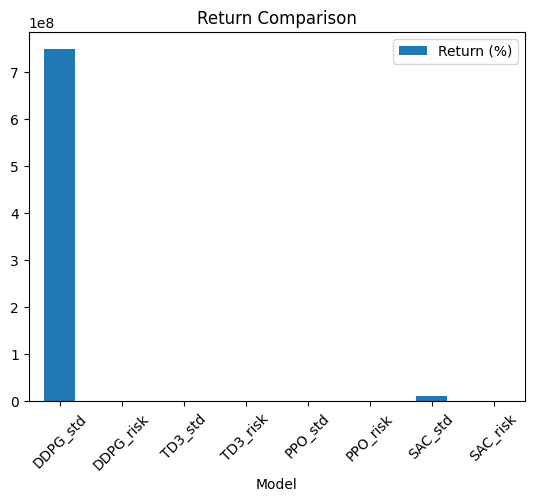

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


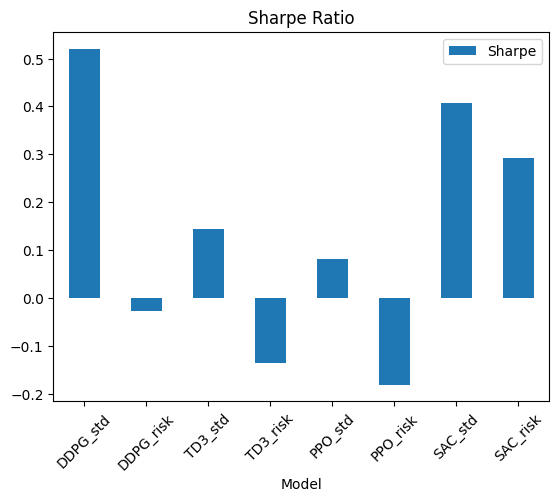

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


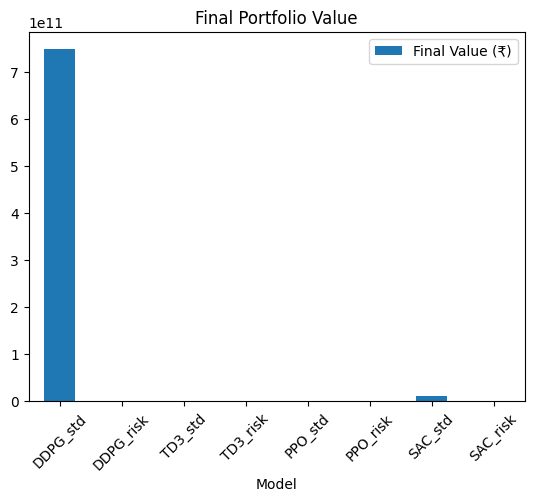

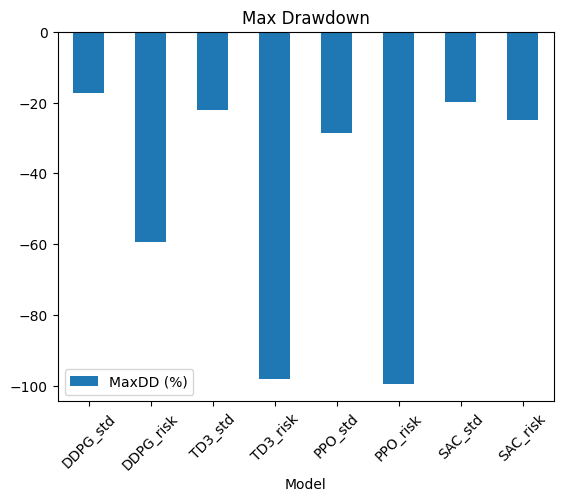

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


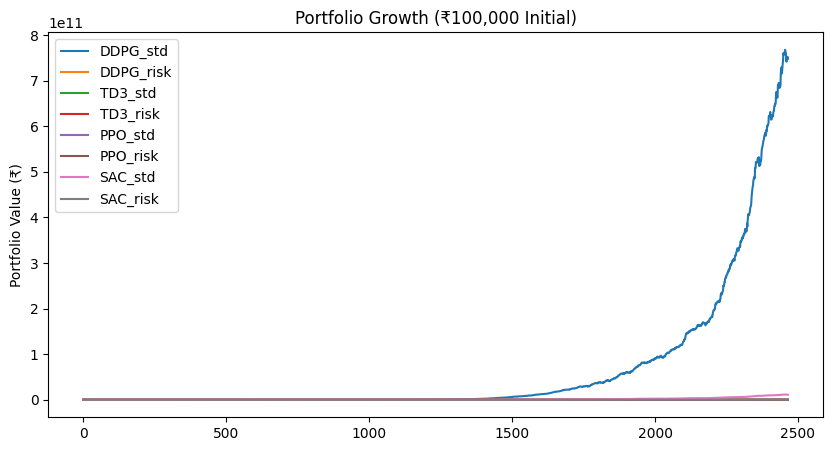

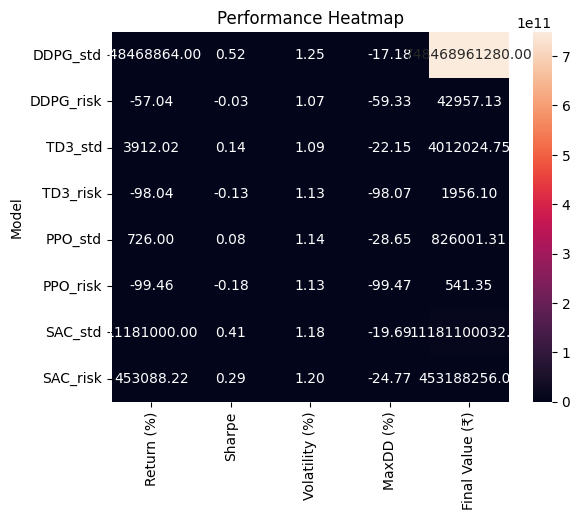

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ===================== INSTALL =====================
!pip -q install stable-baselines3[extra] gymnasium shimmy pandas numpy matplotlib seaborn yfinance pyarrow

# ===================== IMPORTS =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from stable_baselines3 import PPO, DDPG, TD3, SAC
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
from gymnasium import spaces

# ===================== LOAD DATA =====================
FILE_PATH = "/mnt/data/nasdaq100_data.parquet"

try:
    data = pd.read_parquet(FILE_PATH)
    if "Close" in data.columns:
        data = data["Close"]
    print("Loaded dataset")
except:
    print("Fallback to Indian data")
    stocks = ["RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS"]
    data = yf.download(stocks, start="2015-01-01", end="2025-01-01")['Close']

returns = data.pct_change().dropna()

# ===================== ENV =====================
class PortfolioEnv(gym.Env):
    def __init__(self, returns, risk_aware=True, lambda_=0.2, delta=0.001):
        super().__init__()
        self.returns = returns.values
        self.n_assets = returns.shape[1]
        self.t = 0
        self.risk_aware = risk_aware
        self.lambda_ = lambda_
        self.delta = delta
        self.prev_w = np.ones(self.n_assets) / self.n_assets

        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets,))
        self.observation_space = spaces.Box(low=-5, high=5, shape=(self.n_assets,))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        self.prev_w = np.ones(self.n_assets) / self.n_assets
        return self.returns[self.t], {}

    def step(self, action):
        # Softmax allocation
        exp_w = np.exp(action)
        w = exp_w / np.sum(exp_w)

        r = self.returns[self.t]
        portfolio_return = np.dot(w, r)

        # Clip extreme returns
        portfolio_return = np.clip(portfolio_return, -0.05, 0.05)

        # Risk (volatility)
        vol = np.std(self.returns[max(0,self.t-10):self.t+1])

        # Transaction cost
        cost = self.delta * np.sum(np.abs(w - self.prev_w))

        # Risk-aware reward (from your paper)
        if self.risk_aware:
            reward = portfolio_return - self.lambda_ * vol - cost
        else:
            reward = portfolio_return - cost

        # Scale reward for stable RL
        reward = reward * 50 + (0.02 if self.risk_aware else 0.01)

        self.prev_w = w
        self.t += 1
        done = self.t >= len(self.returns)-1

        return self.returns[self.t], reward, done, False, {}

# ===================== TRAIN FUNCTION =====================
def train_model(algo, env):
    model = algo("MlpPolicy", env, verbose=0)
    model.learn(total_timesteps=20000)
    return model

# ===================== CREATE ENVS =====================
env_std = DummyVecEnv([lambda: PortfolioEnv(returns, risk_aware=False)])
env_risk = DummyVecEnv([lambda: PortfolioEnv(returns, risk_aware=True)])

# ===================== TRAIN =====================
algos = {"DDPG":DDPG, "TD3":TD3, "PPO":PPO, "SAC":SAC}
models = {}

for name, algo in algos.items():
    print(f"Training {name}...")
    models[name+"_std"] = train_model(algo, env_std)
    models[name+"_risk"] = train_model(algo, env_risk)

# ===================== EVALUATION =====================
def evaluate(model, env, initial_capital=100000):
    obs = env.reset()
    value = initial_capital
    values = [value]
    rewards = []

    for _ in range(len(returns)-1):
        action, _ = model.predict(obs)
        obs, reward, done, info = env.step(action)

        reward = reward[0] / 50  # reverse scaling

        value = value * (1 + reward)
        values.append(value)
        rewards.append(reward)

        if done:
            break

    rewards = np.array(rewards)

    final_value = value
    total_return = ((value - initial_capital)/initial_capital)*100
    sharpe = np.mean(rewards)/(np.std(rewards)+1e-6)
    vol = np.std(rewards)*100
    max_dd = np.min(np.array(values)/np.maximum.accumulate(values)-1)*100

    return total_return, sharpe, vol, max_dd, final_value, values

# ===================== RESULTS =====================
results = []
curves = {}

for name, model in models.items():
    env = env_risk if "risk" in name else env_std
    ret, sharpe, vol, dd, final_value, values = evaluate(model, env)

    results.append([name, ret, sharpe, vol, dd, final_value])
    curves[name] = values

df = pd.DataFrame(results, columns=[
    "Model","Return (%)","Sharpe","Volatility (%)","MaxDD (%)","Final Value (₹)"
])

print("\n=== FINAL RESULTS (₹100,000 Initial Investment) ===")
display(df.sort_values("Final Value (₹)", ascending=False))

# ===================== PLOTS =====================

# Returns
df.plot(x="Model", y="Return (%)", kind="bar", title="Return Comparison")
plt.xticks(rotation=45); plt.show()

# Sharpe
df.plot(x="Model", y="Sharpe", kind="bar", title="Sharpe Ratio")
plt.xticks(rotation=45); plt.show()

# Final Value
df.plot(x="Model", y="Final Value (₹)", kind="bar", title="Final Portfolio Value")
plt.xticks(rotation=45); plt.show()

# Drawdown
df.plot(x="Model", y="MaxDD (%)", kind="bar", title="Max Drawdown")
plt.xticks(rotation=45); plt.show()

# Portfolio Growth
plt.figure(figsize=(10,5))
for k,v in curves.items():
    plt.plot(v, label=k)
plt.legend()
plt.title("Portfolio Growth (₹100,000 Initial)")
plt.ylabel("Portfolio Value (₹)")
plt.show()

# Heatmap
plt.figure()
sns.heatmap(df.set_index("Model"), annot=True, fmt=".2f")
plt.title("Performance Heatmap")
plt.show()